In [1]:
# ---------------------------------------------------------
# STAGE 13A: LOAD CLEANED DATA
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_survey.csv"
)

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("CUSTOMER SEGMENTATION")
print("=" * 60)

print(f"Dataset shape: {df.shape}")

print("\nDataset loaded successfully.")

CUSTOMER SEGMENTATION
Dataset shape: (11109, 101)

Dataset loaded successfully.


In [2]:
# ---------------------------------------------------------
# STAGE 13B: SELECT SEGMENTATION FEATURES
# ---------------------------------------------------------

segmentation_features = [
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation",
    "digital_purchase_frequency",
    "digital_monthly_spend"
]

print("=" * 60)
print("SEGMENTATION FEATURES")
print("=" * 60)

for feature in segmentation_features:
    print(f"- {feature}")

print(f"\nTotal features: {len(segmentation_features)}")

SEGMENTATION FEATURES
- life_improvement_rating
- service_rating
- content_rating
- price_rating
- delivery_rating
- previous_experience_rating
- brand_solution_rating
- customer_support_rating
- overall_magazine_rating
- overall_experience_rating
- recommendation
- digital_purchase_frequency
- digital_monthly_spend

Total features: 13


In [3]:
# ---------------------------------------------------------
# STAGE 13C: VALIDATE SEGMENTATION DATA
# ---------------------------------------------------------

segmentation_df = df[segmentation_features].copy()

print("=" * 60)
print("SEGMENTATION DATA CHECK")
print("=" * 60)

print(f"Rows    : {segmentation_df.shape[0]:,}")
print(f"Columns : {segmentation_df.shape[1]}")

print("\nMissing values:")
missing = segmentation_df.isnull().sum()

print(
    missing[missing > 0]
)

if missing.sum() == 0:
    print("\n✓ No missing values in segmentation features.")
else:
    print("\n⚠ Missing values detected.")

print("\nData types:")
print(segmentation_df.dtypes)

SEGMENTATION DATA CHECK
Rows    : 11,109
Columns : 13

Missing values:
Series([], dtype: int64)

✓ No missing values in segmentation features.

Data types:
life_improvement_rating       int64
service_rating                int64
content_rating                int64
price_rating                  int64
delivery_rating               int64
previous_experience_rating    int64
brand_solution_rating         int64
customer_support_rating       int64
overall_magazine_rating       int64
overall_experience_rating     int64
recommendation                int64
digital_purchase_frequency      str
digital_monthly_spend           str
dtype: object


In [4]:
# ---------------------------------------------------------
# STAGE 13D: INSPECT SEGMENTATION VARIABLES
# ---------------------------------------------------------

for feature in segmentation_features:
    print("\n" + "=" * 50)
    print(feature)
    print("=" * 50)

    print(
        segmentation_df[feature]
        .value_counts(dropna=False)
        .head(15)
    )


life_improvement_rating
life_improvement_rating
1    2288
2    2227
4    2211
5    2196
3    2187
Name: count, dtype: int64

service_rating
service_rating
1    2302
5    2285
4    2199
3    2175
2    2148
Name: count, dtype: int64

content_rating
content_rating
5    2315
1    2218
3    2195
4    2191
2    2190
Name: count, dtype: int64

price_rating
price_rating
5    2288
1    2254
4    2243
2    2224
3    2100
Name: count, dtype: int64

delivery_rating
delivery_rating
2    2243
3    2230
5    2218
4    2217
1    2201
Name: count, dtype: int64

previous_experience_rating
previous_experience_rating
5    2296
3    2283
1    2209
4    2166
2    2155
Name: count, dtype: int64

brand_solution_rating
brand_solution_rating
2    2275
5    2251
3    2232
4    2225
1    2126
Name: count, dtype: int64

customer_support_rating
customer_support_rating
5    2241
4    2235
3    2226
2    2214
1    2193
Name: count, dtype: int64

overall_magazine_rating
overall_magazine_rating
5    2256
3    2239
1  

In [5]:
# ---------------------------------------------------------
# STAGE 13E: PREPARE DIGITAL BEHAVIOR VARIABLES
# ---------------------------------------------------------

segmentation_model_df = segmentation_df.copy()

# Inspect unique values first
print("Digital purchase frequency values:")
print(
    segmentation_model_df["digital_purchase_frequency"]
    .value_counts()
)

print("\nDigital monthly spend values:")
print(
    segmentation_model_df["digital_monthly_spend"]
    .value_counts()
)

Digital purchase frequency values:
digital_purchase_frequency
Frequently    2234
Regularly     2233
Weekly        2220
Yearly        2219
Monthly       2203
Name: count, dtype: int64

Digital monthly spend values:
digital_monthly_spend
500-1000      2304
1000-2000     2239
Above 5000    2208
2000-5000     2182
Below 500     2176
Name: count, dtype: int64


In [6]:
# Stage 13E: Encode behavioral variables for K-Means

frequency_mapping = {
    "Yearly": 1,
    "Monthly": 2,
    "Regularly": 3,
    "Frequently": 4,
    "Weekly": 5
}

spend_mapping = {
    "Below 500": 1,
    "500-1000": 2,
    "1000-2000": 3,
    "2000-5000": 4,
    "Above 5000": 5
}

segmentation_model_df["digital_purchase_frequency_score"] = (
    segmentation_model_df["digital_purchase_frequency"]
    .map(frequency_mapping)
)

segmentation_model_df["digital_monthly_spend_score"] = (
    segmentation_model_df["digital_monthly_spend"]
    .map(spend_mapping)
)

print("Purchase frequency encoding:")
print(
    segmentation_model_df[
        ["digital_purchase_frequency",
         "digital_purchase_frequency_score"]
    ].drop_duplicates().sort_values(
        "digital_purchase_frequency_score"
    )
)

print("\nMonthly spend encoding:")
print(
    segmentation_model_df[
        ["digital_monthly_spend",
         "digital_monthly_spend_score"]
    ].drop_duplicates().sort_values(
        "digital_monthly_spend_score"
    )
)

Purchase frequency encoding:
   digital_purchase_frequency  digital_purchase_frequency_score
10                     Yearly                                 1
3                     Monthly                                 2
1                   Regularly                                 3
0                  Frequently                                 4
2                      Weekly                                 5

Monthly spend encoding:
  digital_monthly_spend  digital_monthly_spend_score
0             Below 500                            1
5              500-1000                            2
1             1000-2000                            3
3             2000-5000                            4
6            Above 5000                            5


In [7]:
# Stage 13F: Prepare numeric dataset for clustering

segmentation_numeric_features = [
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation",
    "digital_purchase_frequency_score",
    "digital_monthly_spend_score"
]

X_segmentation = segmentation_model_df[
    segmentation_numeric_features
].copy()

print("Segmentation dataset shape:")
print(X_segmentation.shape)

print("\nData types:")
print(X_segmentation.dtypes)

print("\nMissing values:")
print(X_segmentation.isnull().sum().sum())

Segmentation dataset shape:
(11109, 13)

Data types:
life_improvement_rating             int64
service_rating                      int64
content_rating                      int64
price_rating                        int64
delivery_rating                     int64
previous_experience_rating          int64
brand_solution_rating               int64
customer_support_rating             int64
overall_magazine_rating             int64
overall_experience_rating           int64
recommendation                      int64
digital_purchase_frequency_score    int64
digital_monthly_spend_score         int64
dtype: object

Missing values:
0


In [8]:
# Stage 13G: Standardize clustering features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_segmentation)

print("Original shape:", X_segmentation.shape)
print("Scaled shape  :", X_scaled.shape)

print("\nMean of scaled features:")
print(X_scaled.mean(axis=0).round(4))

print("\nStandard deviation of scaled features:")
print(X_scaled.std(axis=0).round(4))

Original shape: (11109, 13)
Scaled shape  : (11109, 13)

Mean of scaled features:
[ 0. -0.  0. -0. -0.  0. -0. -0.  0. -0. -0.  0.  0.]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
# Stage 13H: Evaluate different numbers of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

cluster_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, cluster_labels)
    
    cluster_results.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette
    })

cluster_results_df = pd.DataFrame(cluster_results)

print(cluster_results_df.round(4))

   k      inertia  silhouette_score
0  2  135916.5676            0.0585
1  3  130725.2267            0.0498
2  4  126545.0953            0.0503
3  5  123367.8482            0.0493
4  6  120525.4077            0.0497
5  7  118154.4794            0.0495
6  8  115954.1678            0.0503


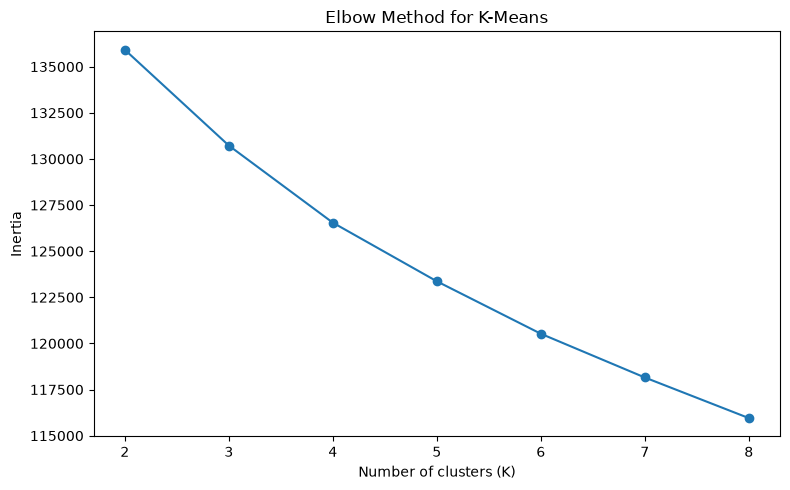

In [10]:
# Stage 13H continued: Visualize inertia and silhouette score

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(
    cluster_results_df["k"],
    cluster_results_df["inertia"],
    marker="o"
)

ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method for K-Means")
ax1.set_xticks(cluster_results_df["k"])

plt.tight_layout()
plt.show()

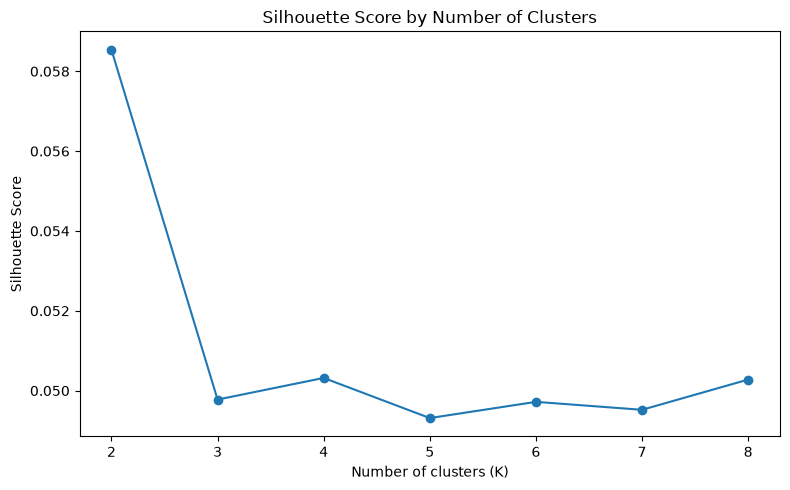

In [11]:
# Stage 13H continued: Silhouette score

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results_df["k"],
    cluster_results_df["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(cluster_results_df["k"])

plt.tight_layout()
plt.show()

In [12]:
# Stage 13I: Final K-Means customer segmentation

from sklearn.cluster import KMeans

FINAL_K = 2

kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

segmentation_model_df["cluster"] = kmeans_final.fit_predict(X_scaled)

print("K-Means model created successfully.")
print(f"Number of clusters: {FINAL_K}")

print("\nCluster sizes:")
print(
    segmentation_model_df["cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster percentages:")
print(
    (
        segmentation_model_df["cluster"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
)

K-Means model created successfully.
Number of clusters: 2

Cluster sizes:
cluster
0    5580
1    5529
Name: count, dtype: int64

Cluster percentages:
cluster
0    50.23
1    49.77
Name: proportion, dtype: float64


In [13]:
# Stage 13J: Profile customer clusters

cluster_profile = (
    segmentation_model_df
    .groupby("cluster")[segmentation_numeric_features]
    .mean()
    .round(2)
)

print("Average profile of each customer cluster:")
print(cluster_profile)

Average profile of each customer cluster:
         life_improvement_rating  service_rating  content_rating  \
cluster                                                            
0                           4.18            3.06            2.92   
1                           1.77            2.94            3.12   

         price_rating  delivery_rating  previous_experience_rating  \
cluster                                                              
0                3.06             2.85                        2.86   
1                2.95             3.16                        3.17   

         brand_solution_rating  customer_support_rating  \
cluster                                                   
0                         3.05                     3.08   
1                         2.98                     2.94   

         overall_magazine_rating  overall_experience_rating  recommendation  \
cluster                                                                       
0        

In [14]:
# Stage 13J continued: Compare cluster sizes

cluster_sizes = (
    segmentation_model_df["cluster"]
    .value_counts()
    .sort_index()
    .rename("customer_count")
    .to_frame()
)

cluster_sizes["percentage"] = (
    cluster_sizes["customer_count"]
    / len(segmentation_model_df)
    * 100
).round(2)

print(cluster_sizes)

         customer_count  percentage
cluster                            
0                  5580       50.23
1                  5529       49.77


In [15]:
# Stage 13K: Create business-friendly segment labels

segment_labels = {
    0: "High Life-Improvement Perception",
    1: "Low Life-Improvement Perception"
}

segmentation_model_df["customer_segment"] = (
    segmentation_model_df["cluster"]
    .map(segment_labels)
)

print(
    segmentation_model_df[
        ["cluster", "customer_segment"]
    ].drop_duplicates().sort_values("cluster")
)

print("\nSegment distribution:")
print(
    segmentation_model_df["customer_segment"]
    .value_counts()
)

   cluster                  customer_segment
0        0  High Life-Improvement Perception
3        1   Low Life-Improvement Perception

Segment distribution:
customer_segment
High Life-Improvement Perception    5580
Low Life-Improvement Perception     5529
Name: count, dtype: int64


In [16]:
# Stage 14A: Complete customer segment profile

profile_features = [
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation",
    "digital_purchase_frequency_score",
    "digital_monthly_spend_score"
]

segment_profile = (
    segmentation_model_df
    .groupby("customer_segment")[profile_features]
    .mean()
    .round(2)
)

print("CUSTOMER SEGMENT PROFILE")
print("=" * 80)
print(segment_profile)

CUSTOMER SEGMENT PROFILE
                                  life_improvement_rating  service_rating  \
customer_segment                                                            
High Life-Improvement Perception                     4.18            3.06   
Low Life-Improvement Perception                      1.77            2.94   

                                  content_rating  price_rating  \
customer_segment                                                 
High Life-Improvement Perception            2.92          3.06   
Low Life-Improvement Perception             3.12          2.95   

                                  delivery_rating  previous_experience_rating  \
customer_segment                                                                
High Life-Improvement Perception             2.85                        2.86   
Low Life-Improvement Perception              3.16                        3.17   

                                  brand_solution_rating  \
customer_segment 

In [17]:
# Stage 14A continued: Repurchase intent by segment

repurchase_profile = (
    segmentation_model_df
    .groupby("customer_segment")["repurchase_intent_score"]
    .agg(
        mean_repurchase_intent="mean",
        median_repurchase_intent="median",
        customer_count="count"
    )
    .round(2)
)

print("REPURCHASE INTENT BY SEGMENT")
print("=" * 80)
print(repurchase_profile)

KeyError: 'Column not found: repurchase_intent_score'

In [18]:
# Stage 14A: Add repurchase intent back to the segmentation dataset

segmentation_model_df["repurchase_intent_score"] = df[
    "repurchase_intent_score"
].values

print("Repurchase intent added successfully.")

print(
    segmentation_model_df[
        ["customer_segment", "repurchase_intent_score"]
    ].head()
)

Repurchase intent added successfully.
                   customer_segment  repurchase_intent_score
0  High Life-Improvement Perception                        3
1  High Life-Improvement Perception                        3
2  High Life-Improvement Perception                        3
3   Low Life-Improvement Perception                        2
4   Low Life-Improvement Perception                        1


In [19]:
# Stage 14A continued: Repurchase intent by segment

repurchase_profile = (
    segmentation_model_df
    .groupby("customer_segment")["repurchase_intent_score"]
    .agg(
        mean_repurchase_intent="mean",
        median_repurchase_intent="median",
        customer_count="count"
    )
    .round(2)
)

print("REPURCHASE INTENT BY SEGMENT")
print("=" * 80)
print(repurchase_profile)

REPURCHASE INTENT BY SEGMENT
                                  mean_repurchase_intent  \
customer_segment                                           
High Life-Improvement Perception                    2.01   
Low Life-Improvement Perception                     2.01   

                                  median_repurchase_intent  customer_count  
customer_segment                                                            
High Life-Improvement Perception                       2.0            5580  
Low Life-Improvement Perception                        2.0            5529  


In [21]:
# Stage 14B: Statistical comparison of customer segments

from scipy.stats import mannwhitneyu
import pandas as pd

segment_0 = segmentation_model_df[
    segmentation_model_df["cluster"] == 0
]

segment_1 = segmentation_model_df[
    segmentation_model_df["cluster"] == 1
]

comparison_features = [
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation",
    "digital_purchase_frequency_score",
    "digital_monthly_spend_score",
    "repurchase_intent_score"
]

# IMPORTANT: initialize the list here
comparison_results = []

for feature in comparison_features:

    statistic, p_value = mannwhitneyu(
        segment_0[feature],
        segment_1[feature],
        alternative="two-sided"
    )

    comparison_results.append({
        "feature": feature,
        "median_cluster_0": segment_0[feature].median(),
        "median_cluster_1": segment_1[feature].median(),
        "u_statistic": statistic,
        "p_value": p_value
    })

segment_comparison_df = pd.DataFrame(comparison_results)

segment_comparison_df = segment_comparison_df.sort_values(
    "p_value"
).reset_index(drop=True)

print("STATISTICAL COMPARISON OF SEGMENTS")
print("=" * 90)

print(
    segment_comparison_df.round(4).to_string(index=False)
)

STATISTICAL COMPARISON OF SEGMENTS
                         feature  median_cluster_0  median_cluster_1  u_statistic  p_value
         life_improvement_rating               4.0               2.0   30257109.0   0.0000
                 delivery_rating               3.0               3.0   13525309.0   0.0000
      previous_experience_rating               3.0               3.0   13540539.5   0.0000
                  content_rating               3.0               3.0   14207739.5   0.0000
       overall_experience_rating               3.0               3.0   14361882.0   0.0000
         customer_support_rating               3.0               3.0   16329271.5   0.0000
                  service_rating               3.0               3.0   16198977.5   0.0000
         overall_magazine_rating               3.0               3.0   16138465.5   0.0000
                    price_rating               3.0               3.0   16109629.5   0.0000
                  recommendation               3.0     

In [22]:
# Stage 14C: Calculate rank-biserial effect sizes

segment_effect_results = []

n0 = len(segment_0)
n1 = len(segment_1)

for feature in comparison_features:

    u_statistic, p_value = mannwhitneyu(
        segment_0[feature],
        segment_1[feature],
        alternative="two-sided"
    )

    # Rank-biserial correlation
    rank_biserial = (
        (2 * u_statistic) / (n0 * n1)
    ) - 1

    segment_effect_results.append({
        "feature": feature,
        "p_value": p_value,
        "rank_biserial_effect": rank_biserial
    })

segment_effect_df = (
    pd.DataFrame(segment_effect_results)
    .sort_values(
        "rank_biserial_effect",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

print("SEGMENT EFFECT SIZES")
print("=" * 80)

print(
    segment_effect_df.round(4).to_string(index=False)
)

SEGMENT EFFECT SIZES
                         feature  p_value  rank_biserial_effect
         life_improvement_rating   0.0000                0.9614
                 delivery_rating   0.0000               -0.1232
      previous_experience_rating   0.0000               -0.1222
                  content_rating   0.0000               -0.0790
       overall_experience_rating   0.0000               -0.0690
         customer_support_rating   0.0000                0.0586
                  service_rating   0.0000                0.0501
         overall_magazine_rating   0.0000                0.0462
                    price_rating   0.0000                0.0443
                  recommendation   0.0006               -0.0367
           brand_solution_rating   0.0073                0.0288
     digital_monthly_spend_score   0.0961                0.0179
digital_purchase_frequency_score   0.6934                0.0042
         repurchase_intent_score   0.9971                0.0000


In [23]:
# Stage 14D: Final business segment summary

segment_summary = (
    segmentation_model_df
    .groupby("customer_segment")
    .agg(
        customers=("customer_segment", "size"),
        avg_life_improvement=("life_improvement_rating", "mean"),
        avg_overall_experience=("overall_experience_rating", "mean"),
        avg_recommendation=("recommendation", "mean"),
        avg_repurchase_intent=("repurchase_intent_score", "mean"),
        avg_digital_frequency=("digital_purchase_frequency_score", "mean"),
        avg_digital_spend=("digital_monthly_spend_score", "mean")
    )
    .reset_index()
)

segment_summary["customer_percentage"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
    * 100
)

segment_summary = segment_summary.round(2)

print("FINAL CUSTOMER SEGMENT SUMMARY")
print("=" * 100)
print(segment_summary.to_string(index=False))

FINAL CUSTOMER SEGMENT SUMMARY
                customer_segment  customers  avg_life_improvement  avg_overall_experience  avg_recommendation  avg_repurchase_intent  avg_digital_frequency  avg_digital_spend  customer_percentage
High Life-Improvement Perception       5580                  4.18                    2.91                2.94                   2.01                   3.01               3.02                50.23
 Low Life-Improvement Perception       5529                  1.77                    3.08                3.03                   2.01                   3.00               2.97                49.77


In [24]:
# Save segment summary for reporting and Power BI

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

OUTPUT_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "customer_segment_summary.csv"
)

segment_summary.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"\nSaved successfully to:")
print(OUTPUT_PATH)


Saved successfully to:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\customer_segment_summary.csv


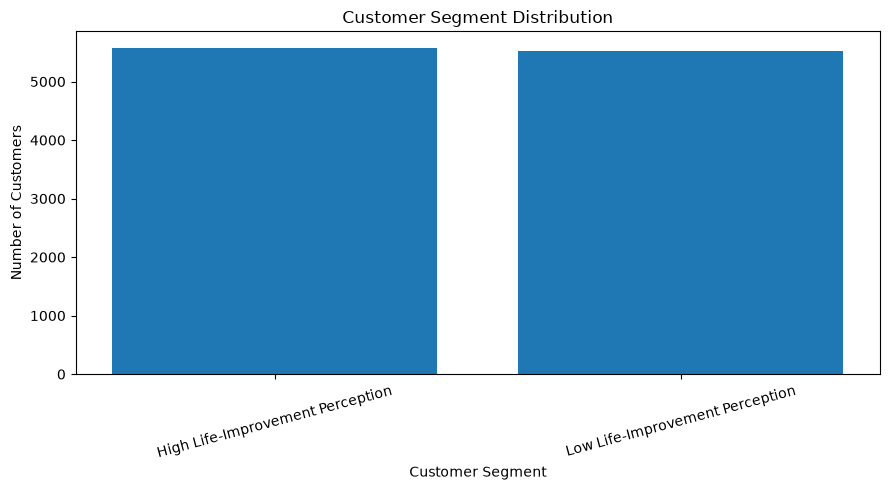

In [25]:
# Stage 15A: Segment size visualization

import matplotlib.pyplot as plt

segment_counts = (
    segmentation_model_df["customer_segment"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<Figure size 1100x600 with 0 Axes>

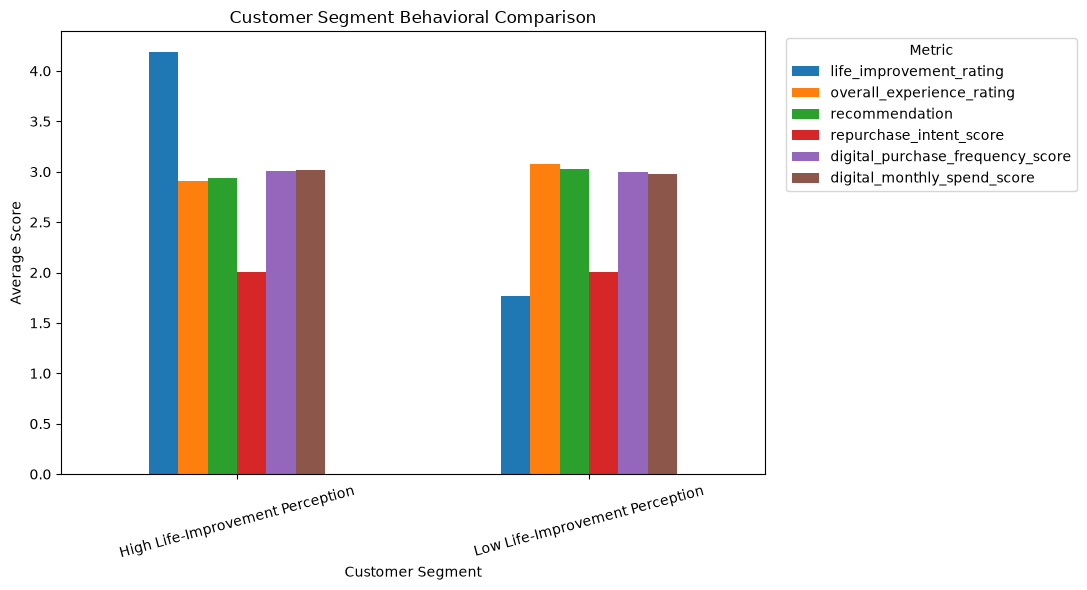

In [26]:
# Stage 15B: Compare key segment characteristics

segment_comparison = (
    segmentation_model_df
    .groupby("customer_segment")[
        [
            "life_improvement_rating",
            "overall_experience_rating",
            "recommendation",
            "repurchase_intent_score",
            "digital_purchase_frequency_score",
            "digital_monthly_spend_score"
        ]
    ]
    .mean()
)

plt.figure(figsize=(11, 6))

segment_comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Customer Segment Behavioral Comparison")
plt.xlabel("Customer Segment")
plt.ylabel("Average Score")

plt.xticks(rotation=15)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [27]:
# Stage 16A: Final customer experience driver analysis

from scipy.stats import spearmanr
import pandas as pd

driver_features = [
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation"
]

target = "repurchase_intent_score"

driver_results = []

for feature in driver_features:

    correlation, p_value = spearmanr(
        df[feature],
        df[target]
    )

    driver_results.append({
        "driver": feature,
        "spearman_correlation": correlation,
        "p_value": p_value
    })

driver_analysis_df = (
    pd.DataFrame(driver_results)
    .sort_values(
        "spearman_correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

print("CUSTOMER LOYALTY DRIVER ANALYSIS")
print("=" * 80)

print(
    driver_analysis_df.round(4).to_string(index=False)
)

CUSTOMER LOYALTY DRIVER ANALYSIS
                    driver  spearman_correlation  p_value
     brand_solution_rating               -0.0212   0.0256
            service_rating               -0.0189   0.0462
           delivery_rating                0.0136   0.1508
 overall_experience_rating                0.0115   0.2260
              price_rating               -0.0103   0.2774
            content_rating                0.0067   0.4822
            recommendation                0.0044   0.6463
   life_improvement_rating               -0.0043   0.6473
   customer_support_rating               -0.0023   0.8062
   overall_magazine_rating                0.0011   0.9092
previous_experience_rating               -0.0001   0.9919


In [28]:
# Stage 16B: Save final driver analysis

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DRIVER_OUTPUT_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "customer_loyalty_driver_analysis.csv"
)

driver_analysis_df.to_csv(
    DRIVER_OUTPUT_PATH,
    index=False
)

print("Driver analysis saved successfully.")
print(DRIVER_OUTPUT_PATH)

Driver analysis saved successfully.
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\customer_loyalty_driver_analysis.csv


In [29]:
# Stage 17A: Create final analytical scorecard

final_scorecard = pd.DataFrame({
    "analysis_area": [
        "Brand Awareness",
        "Loyalty / Repurchase",
        "Customer Segmentation",
        "Digital Behavior",
        "Customer Experience",
        "Loyalty Drivers"
    ],
    
    "key_finding": [
        "No strong evidence that measured marketing variables explain brand awareness.",
        "Repurchase intent shows weak relationships with the measured customer experience variables.",
        "Two exploratory segments were identified, primarily differentiated by perceived life improvement.",
        "Digital purchase frequency and monthly spend do not meaningfully distinguish the two segments.",
        "Customer experience ratings are broadly centered around the midpoint of the 1–5 scale.",
        "No measured experience variable shows a practically meaningful relationship with repurchase intent."
    ],
    
    "business_implication": [
        "Improve the awareness measurement and collect richer campaign exposure data.",
        "Additional behavioral and transactional variables are needed to explain loyalty.",
        "Use perceived life improvement as a segmentation lens, but avoid treating the clusters as definitive personas.",
        "Digital behavior should not be the primary basis for these two segments.",
        "The survey may have limited discriminatory power between customers.",
        "Do not prioritize individual survey ratings as proven loyalty drivers without stronger evidence."
    ]
})

print("FINAL ANALYTICAL SCORECARD")
print("=" * 120)

print(
    final_scorecard.to_string(index=False)
)


FINAL ANALYTICAL SCORECARD
        analysis_area                                                                                         key_finding                                                                                           business_implication
      Brand Awareness                       No strong evidence that measured marketing variables explain brand awareness.                                   Improve the awareness measurement and collect richer campaign exposure data.
 Loyalty / Repurchase         Repurchase intent shows weak relationships with the measured customer experience variables.                               Additional behavioral and transactional variables are needed to explain loyalty.
Customer Segmentation   Two exploratory segments were identified, primarily differentiated by perceived life improvement. Use perceived life improvement as a segmentation lens, but avoid treating the clusters as definitive personas.
     Digital Behavior      Digital purcha

In [30]:
# Stage 17B: Save final analytical scorecard

SCORECARD_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "final_analytical_scorecard.csv"
)

final_scorecard.to_csv(
    SCORECARD_PATH,
    index=False
)

print("\nScorecard saved successfully:")
print(SCORECARD_PATH)


Scorecard saved successfully:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\final_analytical_scorecard.csv


In [31]:
# Stage 18A: Create final Power BI dataset

dashboard_df = df.copy()

# Add customer segment generated by K-Means
dashboard_df["customer_segment"] = segmentation_model_df[
    "customer_segment"
].values

# Add numeric behavioral scores for dashboard analysis
dashboard_df["digital_purchase_frequency_score"] = (
    segmentation_model_df[
        "digital_purchase_frequency_score"
    ].values
)

dashboard_df["digital_monthly_spend_score"] = (
    segmentation_model_df[
        "digital_monthly_spend_score"
    ].values
)

print("Dashboard dataset shape:")
print(dashboard_df.shape)

print("\nCustomer segment distribution:")
print(
    dashboard_df["customer_segment"]
    .value_counts()
)

print("\nMissing values:")
print(
    dashboard_df.isnull().sum().sum()
)

Dashboard dataset shape:
(11109, 104)

Customer segment distribution:
customer_segment
High Life-Improvement Perception    5580
Low Life-Improvement Perception     5529
Name: count, dtype: int64

Missing values:
0


In [32]:
# Stage 18B: Save Power BI-ready dataset

DASHBOARD_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "powerbi_customer_data.csv"
)

dashboard_df.to_csv(
    DASHBOARD_DATA_PATH,
    index=False
)

print("Power BI dataset saved successfully:")
print(DASHBOARD_DATA_PATH)

Power BI dataset saved successfully:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\data\processed\powerbi_customer_data.csv
